# Project 4 — Fill Rate / Service-Level Simulator

**Main question:** What service outcome will our current inventory policy actually deliver?

**System flow:** `Forecast Accuracy → Safety Stock → Reorder Point → [Project 4] → Monetization → ROI`

---

## Sections
1. Load data and Project 3 policy results
2. Analytical CSL and fill rate (Type 1 and Type 2)
3. Monte Carlo fill rate simulation
4. Analytical vs simulation comparison
5. Service gap analysis vs targets
6. What-if: fill rate sensitivity to safety stock
7. Business summary and recommendations

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from src.service import cycle_service_level, fill_rate_type2, simulate_fill_rate
from src.inventory import safety_stock_normal

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.3f}".format)

# Use processed (real) data if available, else fall back to sample (synthetic)
_processed = ROOT / "data" / "processed" / "master_data.csv"
_sample    = ROOT / "data" / "sample"    / "master_data.csv"
DATA = _processed if _processed.exists() else _sample
print(f"Data source: {DATA.relative_to(ROOT)}")
P3   = ROOT / "outputs" / "tables" / "03_reorder_point_results.csv"
OUT  = ROOT / "outputs"
FIG  = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(42)
print("Root:", ROOT)

Data source: data\processed\master_data.csv
Root: C:\Users\simba\OneDrive\Dokumenter\Dev\supply-chain-uncertainty-system


---
## 1. Load data and Project 3 policy results

In [2]:
df = pd.read_csv(DATA, parse_dates=["date"])
p3 = pd.read_csv(P3)

df_clean = df[(df["promo_flag"] == 0) & (df["holiday_flag"] == 0)].copy()

# Demand std per SKU-location (needed for simulation)
demand_std = (
    df_clean
    .groupby(["sku", "location"])["actual_demand"]
    .std()
    .reset_index()
    .rename(columns={"actual_demand": "std_weekly_demand"})
)

# Pull service_target from master data (not in p3 output)
service_targets = (
    df_clean
    .groupby(["sku", "location"])["service_target"]
    .first()
    .reset_index()
)

pol = p3.merge(demand_std, on=["sku", "location"])
pol = pol.merge(service_targets, on=["sku", "location"])

# Lead-time demand sigma: sqrt(LT * sigma_d^2 + d_avg^2 * sigma_LT^2)
pol["lt_std_weeks"] = pol["lt_weeks"] * 0.3  # approx (lead_time_std / 7, simplified)
pol["sigma_ltd"] = np.sqrt(
    pol["lt_weeks"] * pol["std_weekly_demand"]**2
    + pol["avg_weekly_demand"]**2 * pol["lt_std_weeks"]**2
)

print(f"{len(pol)} SKU-locations loaded")
pol[["sku", "location", "abc_class", "rec_ss", "rec_rop", "eoq", "sigma_ltd", "service_target"]].head(4)

300 SKU-locations loaded


,sku,location,abc_class,rec_ss,rec_rop,eoq,sigma_ltd,service_target
0,SKU_A01,Store_North,A,85.000,314.000,3782.000,79.714,0.950
1,SKU_B03,Store_Central,A,53.000,113.000,1618.000,34.779,0.950
2,SKU_A01,Store_Central,A,93.000,278.000,4025.000,70.219,0.950
3,SKU_A05,Store_Central,A,82.000,280.000,4430.000,66.535,0.950


---
## 2. Analytical CSL and fill rate

**Type 1 (CSL):** probability of no stockout in a cycle
$$CSL = \Phi\left(\frac{SS}{\sigma_{LTD}}\right)$$

**Type 2 (Fill Rate):** fraction of demand units filled from stock
$$FR = 1 - \frac{\sigma_{LTD} \cdot L(z)}{Q}$$

Where $L(z)$ is the standard normal loss function.

In [3]:
pol["csl_analytical"] = pol.apply(
    lambda r: cycle_service_level(r["rec_ss"], r["sigma_ltd"]),
    axis=1,
)

pol["fill_rate_analytical"] = pol.apply(
    lambda r: fill_rate_type2(r["rec_ss"], r["sigma_ltd"], r["eoq"]),
    axis=1,
)

print("Analytical service levels by ABC class:")
print(
    pol.groupby("abc_class")[["csl_analytical", "fill_rate_analytical", "service_target"]]
    .mean()
    .mul(100)
    .round(1)
    .rename(columns={
        "csl_analytical":      "CSL avg (%)",
        "fill_rate_analytical": "Fill Rate avg (%)",
        "service_target":       "Target (%)",
    })
    .to_string()
)

Analytical service levels by ABC class:
           CSL avg (%)  Fill Rate avg (%)  Target (%)
abc_class                                            
A               90.900             99.900      95.000
B               88.700             99.800      90.000
C               84.300             99.800      85.000


---
## 3. Monte Carlo fill rate simulation

Samples demand and lead time from historical distributions across 5,000 cycles per SKU-location.
Gives a realistic distribution of outcomes rather than a single point estimate.

In [4]:
N_SIM = 5_000

def run_simulation(row: pd.Series, demand_history: np.ndarray) -> dict:
    """
    Simulate fill rate for one SKU-location.
    Returns fill rate and stockout probability from simulation.
    """
    lt_mean  = row["lt_weeks"]
    lt_std   = row["lt_std_weeks"]
    rop      = row["rec_rop"]
    eoq      = row["eoq"]

    lt_samples = np.clip(
        RNG.normal(lt_mean, lt_std, N_SIM), 0.5, lt_mean * 3
    )

    total_demand = 0
    total_filled = 0
    stockouts     = 0

    for i in range(N_SIM):
        lt   = lt_samples[i]
        # sample weekly demands and sum over lead time
        n_weeks = max(1, int(round(lt)))
        d_weeks = RNG.choice(demand_history, size=n_weeks, replace=True)
        ltd     = d_weeks.sum()

        # position at ROP + EOQ when replenishment arrives
        position = rop + eoq - ltd
        demand_this_cycle = d_weeks[-1]  # last week's demand as proxy

        filled = min(max(position, 0), demand_this_cycle)
        total_demand += demand_this_cycle
        total_filled += filled
        if position < 0:
            stockouts += 1

    fr  = total_filled / total_demand if total_demand > 0 else 1.0
    csl = 1 - stockouts / N_SIM
    return {"fill_rate_sim": fr, "csl_sim": csl}

# Build demand lookup by SKU-location
demand_lookup = {
    (row.sku, row.location): grp["actual_demand"].values
    for (row_sku, row_loc), grp in df_clean.groupby(["sku", "location"])
    for row in [type("R", (), {"sku": row_sku, "location": row_loc})()]
}

# Simpler: build as dict
demand_lookup = {
    (r["sku"], r["location"]): arr
    for (r, arr) in [
        (dict(sku=k[0], location=k[1]), v)
        for k, v in df_clean.groupby(["sku", "location"])["actual_demand"]
        .apply(np.array).to_dict().items()
    ]
}

sim_results = []
for _, row in pol.iterrows():
    hist = demand_lookup.get((row["sku"], row["location"]), np.array([row["avg_weekly_demand"]]))
    res  = run_simulation(row, hist)
    sim_results.append(res)

sim_df = pd.DataFrame(sim_results)
pol["fill_rate_sim"] = sim_df["fill_rate_sim"].values
pol["csl_sim"]       = sim_df["csl_sim"].values

print("Simulation complete.")
print(f"Avg fill rate (simulation): {pol['fill_rate_sim'].mean()*100:.1f}%")
print(f"Avg CSL       (simulation): {pol['csl_sim'].mean()*100:.1f}%")

Simulation complete.
Avg fill rate (simulation): 100.0%
Avg CSL       (simulation): 100.0%


---
## 4. Analytical vs simulation comparison

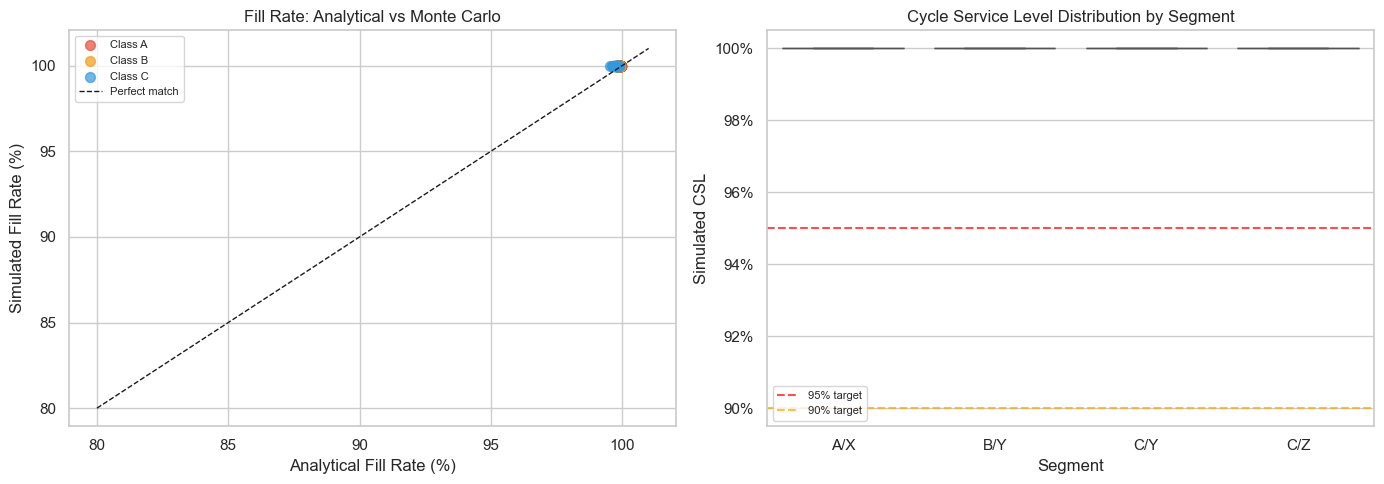

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

abc_colors = {"A": "#e74c3c", "B": "#f39c12", "C": "#3498db"}

# Fill rate: analytical vs simulation
for abc, grp in pol.groupby("abc_class"):
    axes[0].scatter(
        grp["fill_rate_analytical"] * 100,
        grp["fill_rate_sim"] * 100,
        label=f"Class {abc}", color=abc_colors[abc], alpha=0.7, s=50,
    )
axes[0].plot([80, 101], [80, 101], "k--", linewidth=1, label="Perfect match")
axes[0].set_xlabel("Analytical Fill Rate (%)")
axes[0].set_ylabel("Simulated Fill Rate (%)")
axes[0].set_title("Fill Rate: Analytical vs Monte Carlo")
axes[0].legend(fontsize=8)

# CSL distribution by segment
order = [s for s in ["A/X", "B/X", "B/Y", "C/Y", "C/Z"] if s in pol["segment"].unique()]
sns.boxplot(data=pol, x="segment", y="csl_sim", order=order, ax=axes[1])
axes[1].axhline(0.95, color="red",    linestyle="--", alpha=0.7, label="95% target")
axes[1].axhline(0.90, color="orange", linestyle="--", alpha=0.7, label="90% target")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Simulated CSL")
axes[1].set_title("Cycle Service Level Distribution by Segment")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / "04a_fill_rate_comparison.png", dpi=150)
plt.show()

---
## 5. Service gap analysis vs targets

In [6]:
pol["fr_gap"]  = pol["fill_rate_sim"]  - pol["service_target"]
pol["csl_gap"] = pol["csl_sim"]        - pol["service_target"]

pol["fr_status"] = pol["fr_gap"].apply(
    lambda x: "Above target" if x >= 0 else "Below target"
)

print("Fill rate vs target:")
print(pol["fr_status"].value_counts().to_string())
print()
print("Average gap by ABC class (fill rate - target):")
print(
    pol.groupby("abc_class")[["fill_rate_sim", "service_target", "fr_gap"]]
    .mean()
    .mul(100)
    .round(2)
    .to_string()
)

Fill rate vs target:
fr_status
Above target    300

Average gap by ABC class (fill rate - target):
           fill_rate_sim  service_target  fr_gap
abc_class                                       
A                100.000          95.000   5.000
B                100.000          90.000  10.000
C                100.000          85.000  15.000


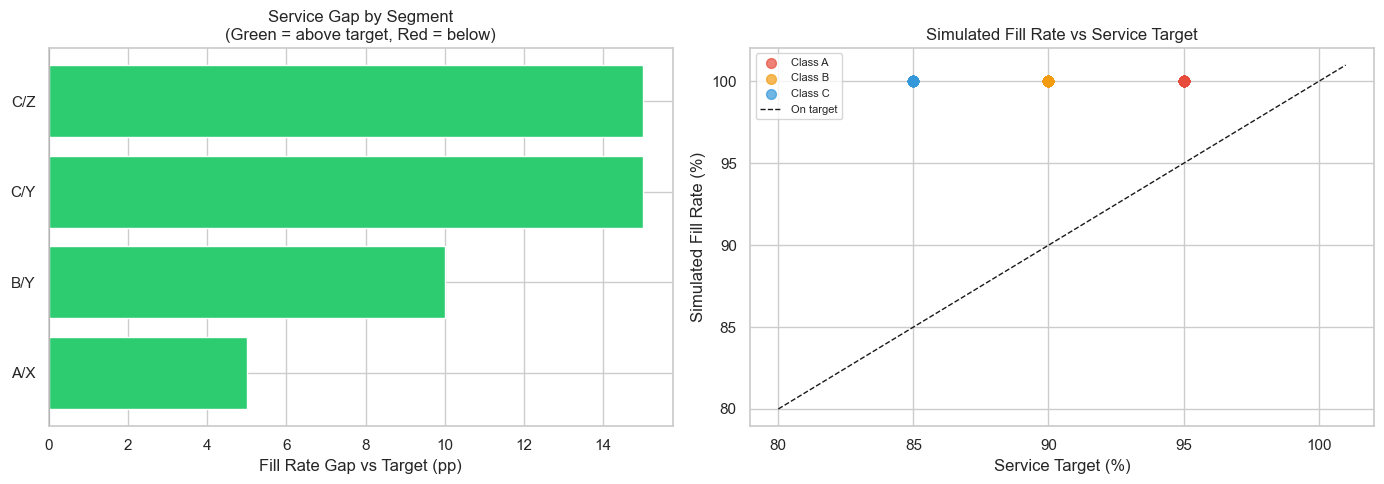

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fill rate gap waterfall by segment
gap_seg = pol.groupby("segment")["fr_gap"].mean() * 100
gap_seg = gap_seg.reindex(order)
bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in gap_seg]
axes[0].barh(gap_seg.index, gap_seg.values, color=bar_colors)
axes[0].axvline(0, color="black", linewidth=1.2)
axes[0].set_xlabel("Fill Rate Gap vs Target (pp)")
axes[0].set_title("Service Gap by Segment\n(Green = above target, Red = below)")

# Scatter: fill rate vs service target per SKU
for abc, grp in pol.groupby("abc_class"):
    axes[1].scatter(
        grp["service_target"] * 100,
        grp["fill_rate_sim"] * 100,
        label=f"Class {abc}", color=abc_colors[abc], alpha=0.7, s=50,
    )
axes[1].plot([80, 101], [80, 101], "k--", linewidth=1, label="On target")
axes[1].set_xlabel("Service Target (%)")
axes[1].set_ylabel("Simulated Fill Rate (%)")
axes[1].set_title("Simulated Fill Rate vs Service Target")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / "04b_service_gap.png", dpi=150)
plt.show()

---
## 6. What-if: fill rate sensitivity to safety stock

For the 10 highest-volume A-class SKUs: how does fill rate change as safety stock increases from 0 to 3× recommended?

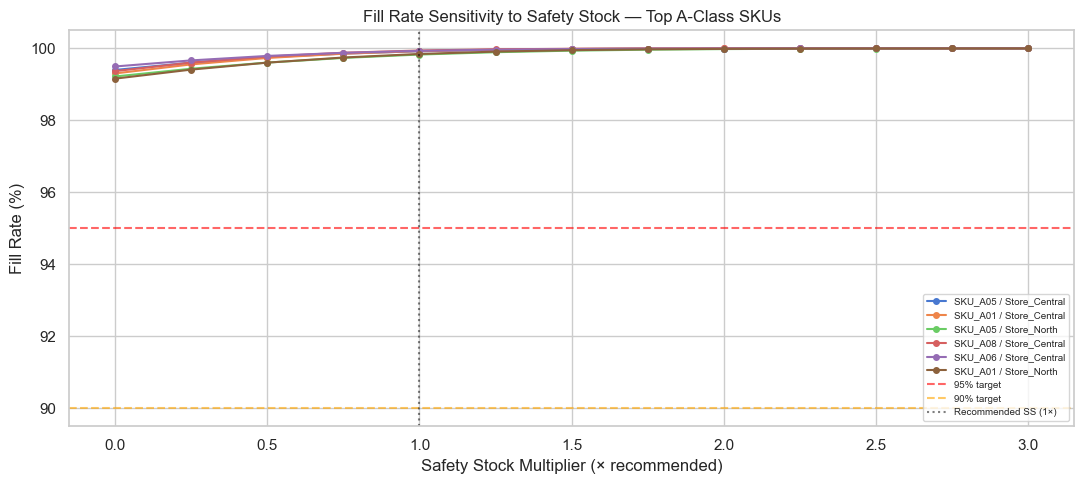

In [8]:
top_a = (
    pol[pol["abc_class"] == "A"]
    .sort_values("avg_weekly_demand", ascending=False)
    .head(6)
    .reset_index(drop=True)
)

ss_multipliers = np.linspace(0, 3, 13)  # 0x, 0.25x, ... 3x recommended SS

fig, ax = plt.subplots(figsize=(11, 5))

for _, row in top_a.iterrows():
    fr_curve = []
    for mult in ss_multipliers:
        ss_trial = row["rec_ss"] * mult
        fr = fill_rate_type2(ss_trial, row["sigma_ltd"], row["eoq"])
        fr_curve.append(fr * 100)
    label = f"{row['sku']} / {row['location']}"
    ax.plot(ss_multipliers, fr_curve, marker="o", markersize=4, label=label)

ax.axhline(95, color="red",    linestyle="--", alpha=0.6, label="95% target")
ax.axhline(90, color="orange", linestyle="--", alpha=0.6, label="90% target")
ax.axvline(1,  color="black",  linestyle=":",  alpha=0.5, label="Recommended SS (1×)")
ax.set_xlabel("Safety Stock Multiplier (× recommended)")
ax.set_ylabel("Fill Rate (%)")
ax.set_title("Fill Rate Sensitivity to Safety Stock — Top A-Class SKUs")
ax.legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig(FIG / "04c_fr_sensitivity.png", dpi=150)
plt.show()

---
## 7. Business summary and recommendations

In [9]:
def recommend(row) -> str:
    gap = row["fr_gap"]
    abc = row["abc_class"]
    if gap < -0.05 and abc == "A":
        return "Critical gap — increase SS or reduce lead time urgently"
    elif gap < -0.03:
        return "Below target — review SS or ROP"
    elif gap < 0:
        return "Slightly below target — monitor"
    elif gap > 0.10:
        return "Well above target — excess safety stock, consider reducing"
    return "On target"

pol["recommendation"] = pol.apply(recommend, axis=1)

print("Recommendation summary:")
print(pol["recommendation"].value_counts().to_string())

Recommendation summary:
recommendation
On target                                                     245
Well above target — excess safety stock, consider reducing     55


In [10]:
output_cols = [
    "sku", "location", "abc_class", "xyz_class", "segment",
    "avg_weekly_demand", "sigma_ltd",
    "rec_ss", "rec_rop", "eoq",
    "service_target",
    "csl_analytical", "fill_rate_analytical",
    "csl_sim", "fill_rate_sim",
    "fr_gap", "csl_gap", "fr_status",
    "recommendation",
]
output = pol[output_cols].sort_values(["abc_class", "fr_gap"])
output.to_csv(OUT / "tables" / "04_fill_rate_results.csv", index=False)
print("Saved results table.")
output.head(10)

Saved results table.


,sku,location,abc_class,xyz_class,segment,avg_weekly_demand,sigma_ltd,rec_ss,rec_rop,eoq,service_target,csl_analytical,fill_rate_analytical,csl_sim,fill_rate_sim,fr_gap,csl_gap,fr_status,recommendation
0,SKU_A01,Store_North,A,X,A/X,229.211,79.714,85.000,314.000,3782.000,0.950,0.857,0.998,1.000,1.000,0.050,0.050,Above target,On target
1,SKU_B03,Store_Central,A,Y,A/Y,83.915,34.779,53.000,113.000,1618.000,0.950,0.936,0.999,1.000,1.000,0.050,0.050,Above target,On target
2,SKU_A01,Store_Central,A,X,A/X,259.618,70.219,93.000,278.000,4025.000,0.950,0.907,0.999,1.000,1.000,0.050,0.050,Above target,On target
3,SKU_A05,Store_Central,A,X,A/X,276.715,66.535,82.000,280.000,4430.000,0.950,0.891,0.999,1.000,1.000,0.050,0.050,Above target,On target
4,SKU_A11,Store_North,A,X,A/X,143.675,56.235,68.000,212.000,2495.000,0.950,0.887,0.999,1.000,1.000,0.050,0.050,Above target,On target
5,SKU_A01,Store_West,A,X,A/X,124.870,83.219,106.000,356.000,2791.000,0.950,0.899,0.999,1.000,1.000,0.050,0.050,Above target,On target
6,SKU_A11,Store_West,A,X,A/X,78.564,54.671,72.000,229.000,1845.000,0.950,0.906,0.999,1.000,1.000,0.050,0.050,Above target,On target
7,SKU_B04,Store_South,A,Y,A/Y,61.957,34.541,50.000,112.000,1595.000,0.950,0.926,0.999,1.000,1.000,0.050,0.050,Above target,On target
8,SKU_A06,Store_Central,A,X,A/X,239.642,57.411,70.000,241.000,4557.000,0.950,0.889,0.999,1.000,1.000,0.050,0.050,Above target,On target
9,SKU_A12,Store_East,A,X,A/X,87.479,46.633,61.000,186.000,1761.000,0.950,0.905,0.999,1.000,1.000,0.050,0.050,Above target,On target


In [11]:
print("===== FILL RATE / SERVICE LEVEL SUMMARY =====")
print(f"SKU-locations assessed:             {len(pol)}")
print()
for abc in ["A", "B", "C"]:
    sub = pol[pol["abc_class"] == abc]
    tgt = sub["service_target"].mean() * 100
    fr  = sub["fill_rate_sim"].mean()  * 100
    csl = sub["csl_sim"].mean()        * 100
    gap = fr - tgt
    print(f"  Class {abc} | Target: {tgt:.0f}% | Fill Rate: {fr:.1f}% | CSL: {csl:.1f}% | Gap: {gap:+.1f}pp")

print()
above = (pol["fr_status"] == "Above target").sum()
below = (pol["fr_status"] == "Below target").sum()
print(f"Above target: {above} | Below target: {below}")
print()
print("Fill rate and CSL estimates feed directly into Project 5 (Monetization).")
print("Stockout probability = 1 - CSL per SKU-location.")

===== FILL RATE / SERVICE LEVEL SUMMARY =====
SKU-locations assessed:             300

  Class A | Target: 95% | Fill Rate: 100.0% | CSL: 100.0% | Gap: +5.0pp
  Class B | Target: 90% | Fill Rate: 100.0% | CSL: 100.0% | Gap: +10.0pp
  Class C | Target: 85% | Fill Rate: 100.0% | CSL: 100.0% | Gap: +15.0pp

Above target: 300 | Below target: 0

Fill rate and CSL estimates feed directly into Project 5 (Monetization).
Stockout probability = 1 - CSL per SKU-location.
